In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۶ — تکنیک‌های یادگیری تجمیعی
## درس ۱۱: داده‌های نامتوازن با انسامبل‌ها (وزن‌دهی کلاس‌ها، جنگل تصادفی متوازن، آستانه‌گذاری)

این نوت‌بوک طوری نوشته شده که **از زنجیره‌ی خطاهای NameError** جلوگیری کند (حتی اگر سلول‌ها را خارج از ترتیب اجرا کنید):

- هر بخش دیتاست از طریق توابع `get_*()` اجرا می‌شود که همه‌ی متغیرهای لازم را **محاسبه و cache** می‌کنند.
- اگر split به‌صورت تصادفی باعث شود در train فقط یک کلاس داشته باشیم، با seedهای متفاوت **retry** می‌کنیم.
- برای دیتاست NYC، ستون‌های مصدومیت را **خودکار** تشخیص می‌دهیم چون خروجی‌ها متفاوت‌اند.

> بهترین روش: **Kernel → Restart & Run All**. اما این نوت‌بوک حتی در اجرای انتخابی هم پایدار است.

از چند دیتاست ریپوی شما استفاده می‌کنیم:

- `diabetes.csv` (دودویی)  
- `drug200.csv` (چندکلاسه → دودویی‌سازی رویداد نادر)  
- `Wine_Quality.csv` (رویداد نادر «واین خوب»)  
- `NYC_Collisions.csv` (رویداد نادر شدید)  
- `salaries.csv` (نمونه‌ی ساده برای رویداد نادر حقوق بالا)  
- `glass.csv` (نامتوازن چندکلاسه)

**یادآوری:** در عدم‌توازن، PR-AUC و نقاط عملیاتی (precision/recall در آستانه‌ها) مهم‌تر از accuracy است.

---

### چند فرمول تئوری (با $ و $$)

Accuracy طبقه‌بند همیشه منفی با شیوع $\pi=P(Y=1)$:

$$
\text{Acc} = 1-\pi.
$$

آستانه‌ی بهینه‌ی بیزی با هزینه‌های $C_{FP},C_{FN}$:

$$
\tau^*=\frac{C_{FP}}{C_{FP}+C_{FN}}.
$$


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.base import BaseEstimator, ClassifierMixin

np.random.seed(42)

# OneHotEncoder compatibility across sklearn versions
try:
    from sklearn.preprocessing import OneHotEncoder
    _ = OneHotEncoder(sparse_output=False)
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    from sklearn.preprocessing import OneHotEncoder
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

CACHE = {}  # section-level caching to avoid NameError cascades

def read_csv_rel(rel_path: str) -> pd.DataFrame:
    p = Path(rel_path)
    if not p.exists():
        raise FileNotFoundError(f"CSV not found: {p.resolve()}")
    return pd.read_csv(p)

def split_X_y(df: pd.DataFrame, target: str):
    if target not in df.columns:
        raise KeyError(f"Target '{target}' not found. Columns: {list(df.columns)[:30]} ...")
    return df.drop(columns=[target]).copy(), df[target].copy()

def make_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def require_two_classes(y, name="y"):
    u = pd.Series(y).dropna().unique()
    if len(u) < 2:
        raise ValueError(f"{name} has <2 classes. Unique values: {u}. Check label mapping / threshold / split.")
    return u

def safe_train_test_split(X, y, test_size=0.25, random_state=42, max_tries=25):
    # Retry stratified splits with different seeds until both train and test contain both classes.
    y = pd.Series(y)
    require_two_classes(y, "y (before split)")
    for k in range(max_tries):
        rs = random_state + k
        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=test_size, random_state=rs, stratify=y
        )
        if pd.Series(ytr).nunique() >= 2 and pd.Series(yte).nunique() >= 2:
            return Xtr, Xte, ytr.astype(int), yte.astype(int), rs
    raise ValueError("Could not create a stratified split with both classes in train and test. Consider relaxing the label definition.")

def summarize_binary_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "BalancedAcc": float(balanced_accuracy_score(y_true, y_pred)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
        "ROC_AUC": float(roc_auc_score(y_true, y_score)),
        "PR_AUC": float(average_precision_score(y_true, y_score)),
        "Brier": float(brier_score_loss(y_true, y_score)),
        "Precision": float(tp / (tp + fp + 1e-12)),
        "Recall": float(tp / (tp + fn + 1e-12)),
    }

def plot_pr_roc(y_true, y_score, label: str):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve — {label} (AP={ap:.3f})")
    plt.grid(True)
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {label} (AUC={auc:.3f})")
    plt.grid(True)
    plt.show()

def plot_calibration(y_true, y_score, label: str, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy="uniform")
    plt.figure()
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Reliability Diagram — {label}")
    plt.grid(True)
    plt.show()

def f_beta(prec, rec, beta=1.0, eps=1e-12):
    beta2 = beta**2
    return (1 + beta2) * (prec * rec) / (beta2 * prec + rec + eps)

def threshold_sweep(y_true, y_score, thresholds=None, C_fp=1.0, C_fn=5.0):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        prec = tp / (tp + fp + 1e-12)
        rec = tp / (tp + fn + 1e-12)
        rows.append({
            "thr": float(t),
            "Precision": float(prec),
            "Recall": float(rec),
            "F1": float(f_beta(prec, rec, beta=1.0)),
            "F2": float(f_beta(prec, rec, beta=2.0)),
            f"Cost(Cfp={C_fp:.1f},Cfn={C_fn:.1f})": float(C_fp*fp + C_fn*fn),
        })
    return pd.DataFrame(rows)

def best_threshold_by(df_sweep: pd.DataFrame, col: str):
    if col in ["F1", "F2"]:
        row = df_sweep.loc[df_sweep[col].idxmax()]
    else:
        row = df_sweep.loc[df_sweep[col].idxmin()]
    return float(row["thr"]), row

def threshold_for_precision(y_true, y_score, precision_target=0.90):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    ok = prec[:-1] >= precision_target
    if not np.any(ok):
        return None, None
    idx = np.argmax(rec[:-1][ok])
    thr_feasible = thr[ok]
    rec_feasible = rec[:-1][ok]
    return float(thr_feasible[idx]), float(rec_feasible[idx])

def eval_table(y_true, y_score, thresholds):
    rows = []
    for name, t in thresholds.items():
        y_pred = (y_score >= t).astype(int)
        rows.append(pd.Series(summarize_binary_metrics(y_true, y_pred, y_score), name=f"{name} (thr={t:.2f})"))
    return pd.DataFrame(rows)

def show_operating_point(y_true, y_score, thr, label):
    if thr is None:
        print(f"{label}: no feasible threshold.")
        return
    y_pred = (y_score >= thr).astype(int)
    s = pd.Series(summarize_binary_metrics(y_true, y_pred, y_score), name=f"{label} (thr={thr:.3f})")
    display(s)

class BalancedBaggingBinary(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator=None, n_estimators=80, random_state=42):
        self.base_estimator = base_estimator if base_estimator is not None else LogisticRegression(max_iter=3000, solver="lbfgs")
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models_ = []

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X)
        y = np.asarray(y)

        idx_pos = np.where(y == 1)[0]
        idx_neg = np.where(y == 0)[0]
        m = min(len(idx_pos), len(idx_neg))
        if m == 0:
            raise ValueError("Need at least one sample from each class. Check label mapping.")

        self.models_ = []
        for _ in range(self.n_estimators):
            s_pos = rng.choice(idx_pos, size=m, replace=True)
            s_neg = rng.choice(idx_neg, size=m, replace=True)
            idx = np.concatenate([s_pos, s_neg])
            rng.shuffle(idx)
            model = clone(self.base_estimator)
            model.fit(X[idx], y[idx])
            self.models_.append(model)
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        probs = [m.predict_proba(X)[:, 1] for m in self.models_]
        p_mean = np.mean(np.vstack(probs), axis=0)
        return np.vstack([1 - p_mean, p_mean]).T


## ۱) دیابت (دودویی) — وزن‌دهی، balanced RF، آستانه‌گذاری

**دام رایج (رفع شد):** هرگز برای mapping برچسب‌ها از `contains("diab")` استفاده نکنید، چون `"Non-Diabetic"` هم `"diab"` دارد.  
ما این‌طور map می‌کنیم: **اگر برچسب شامل `"non"` باشد منفی (0)** وگرنه مثبت (1).

پس از سلول ابزارها، می‌توانید سلول‌های این بخش را با هر ترتیبی اجرا کنید چون هر سلول `get_diabetes()` / `get_diabetes_preds()` را فراخوانی می‌کند.



In [3]:
def get_diabetes():
    if "diabetes" in CACHE:
        return CACHE["diabetes"]

    df = read_csv_rel("../../../Datasets/Classification/diabetes.csv")
    target = "classification"
    X, y = split_X_y(df, target)

    y_str = y.astype(str).str.strip().str.lower()
    y_bin = (~y_str.str.contains("non")).astype(int)  # Non-* => 0, else 1
    require_two_classes(y_bin, "diabetes y_bin")

    X_train, X_test, y_train, y_test, rs = safe_train_test_split(X, y_bin, test_size=0.25, random_state=42)

    out = {
        "df": df, "X": X, "y_raw": y, "y_bin": y_bin,
        "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test,
        "random_state_used": rs
    }
    CACHE["diabetes"] = out
    return out

def get_diabetes_preds():
    if "diabetes_preds" in CACHE:
        return CACHE["diabetes_preds"]

    d = get_diabetes()
    X_train, X_test = d["X_train"], d["X_test"]
    y_train, y_test = d["y_train"], d["y_test"]

    pre = make_preprocessor(X_train)

    # Baselines
    pipe_lr = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, solver="lbfgs"))])
    pipe_rf = Pipeline([("pre", pre), ("clf", RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1))])

    pipe_lr.fit(X_train, y_train)
    pipe_rf.fit(X_train, y_train)

    p_lr = pipe_lr.predict_proba(X_test)[:, 1]
    p_rf = pipe_rf.predict_proba(X_test)[:, 1]

    # class_weight variants
    pipe_lr_w = Pipeline([("pre", make_preprocessor(X_train)),
                          ("clf", LogisticRegression(max_iter=3000, solver="lbfgs", class_weight="balanced"))])
    pipe_rf_bsub = Pipeline([("pre", make_preprocessor(X_train)),
                             ("clf", RandomForestClassifier(n_estimators=900, random_state=42, n_jobs=-1,
                                                           class_weight="balanced_subsample"))])

    pipe_lr_w.fit(X_train, y_train)
    pipe_rf_bsub.fit(X_train, y_train)

    p_lr_w = pipe_lr_w.predict_proba(X_test)[:, 1]
    p_rf_bsub = pipe_rf_bsub.predict_proba(X_test)[:, 1]

    # sample_weight example (GB)
    w_pos = (y_train==0).sum() / max((y_train==1).sum(), 1)
    sample_w = np.where(y_train==1, w_pos, 1.0)
    pipe_gb = Pipeline([("pre", make_preprocessor(X_train)),
                        ("clf", GradientBoostingClassifier(random_state=42))])
    pipe_gb.fit(X_train, y_train, clf__sample_weight=sample_w)
    p_gb = pipe_gb.predict_proba(X_test)[:, 1]

    out = {
        "y_test": y_test,
        "p_lr": p_lr, "p_rf": p_rf,
        "p_lr_w": p_lr_w,
        "p_rf_bsub": p_rf_bsub,
        "p_gb": p_gb,
        "pipe_rf_bsub": pipe_rf_bsub,
        "X_train": X_train, "y_train": y_train, "X_test": X_test
    }
    CACHE["diabetes_preds"] = out
    return out


In [4]:
d = get_diabetes()
print("Diabetes: random_state used for split:", d["random_state_used"])

display(d["y_raw"].value_counts(dropna=False))
display(d["y_bin"].value_counts().rename("count"))
display(d["y_bin"].value_counts(normalize=True).rename("proportion"))

d["df"].head()

Diabetes: random_state used for split: 42


classification
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

classification
0    500
1    268
Name: count, dtype: int64

classification
0    0.651042
1    0.348958
Name: proportion, dtype: float64

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,classification
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non-Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non-Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


In [5]:
p = get_diabetes_preds()
y_test = p["y_test"]

df_metrics = pd.DataFrame([
    summarize_binary_metrics(y_test, (p["p_lr"]>=0.5).astype(int), p["p_lr"]),
    summarize_binary_metrics(y_test, (p["p_rf"]>=0.5).astype(int), p["p_rf"]),
    summarize_binary_metrics(y_test, (p["p_lr_w"]>=0.5).astype(int), p["p_lr_w"]),
    summarize_binary_metrics(y_test, (p["p_rf_bsub"]>=0.5).astype(int), p["p_rf_bsub"]),
    summarize_binary_metrics(y_test, (p["p_gb"]>=0.5).astype(int), p["p_gb"]),
], index=[
    "LR (thr=0.5)",
    "RF (thr=0.5)",
    "LR (class_weight=balanced)",
    "RF (balanced_subsample)",
    "GB (sample_weight positives)",
]).T

df_metrics

,LR (thr=0.5),RF (thr=0.5),LR (class_weight=balanced),RF (balanced_subsample),GB (sample_weight positives)
TP,35.000000,39.000000,49.000000,39.000000,43.000000
FP,19.000000,20.000000,28.000000,18.000000,27.000000
TN,106.000000,105.000000,97.000000,107.000000,98.000000
FN,32.000000,28.000000,18.000000,28.000000,24.000000
BalancedAcc,0.685194,0.711045,0.753672,0.719045,0.712896
MCC,0.392657,0.436059,0.493401,0.457037,0.421658
ROC_AUC,0.832000,0.816716,0.832955,0.821134,0.822925
PR_AUC,0.712428,0.705561,0.717301,0.703816,0.717242
Brier,0.162722,0.164042,0.168460,0.162374,0.172149
Precision,0.648148,0.661017,0.636364,0.684211,0.614286


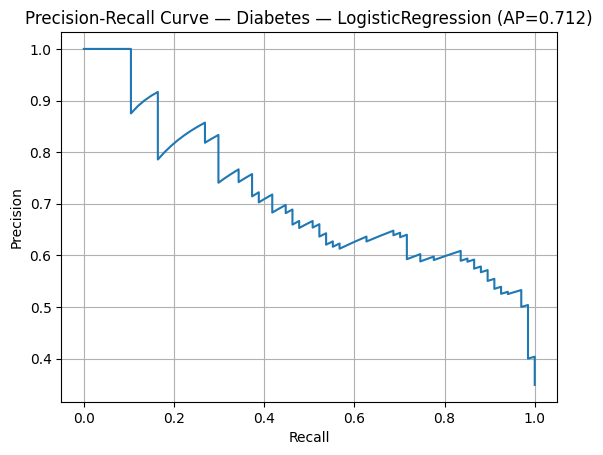

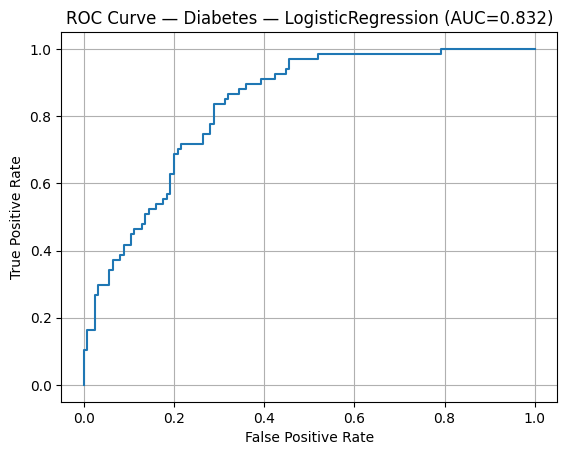

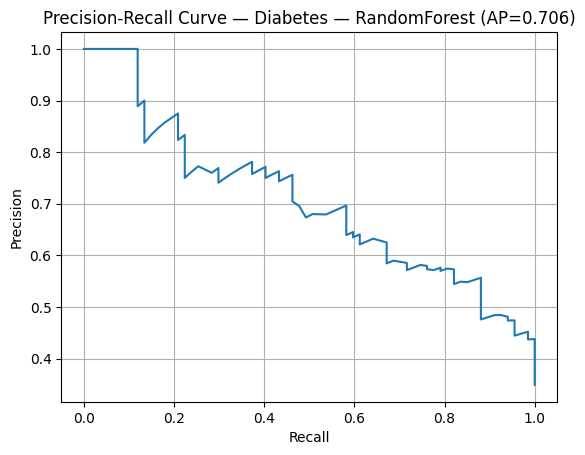

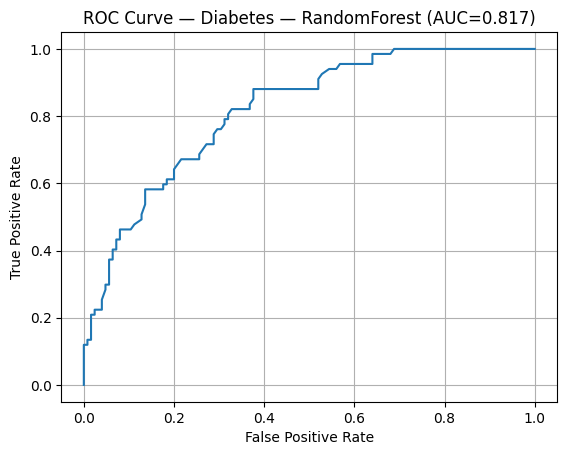

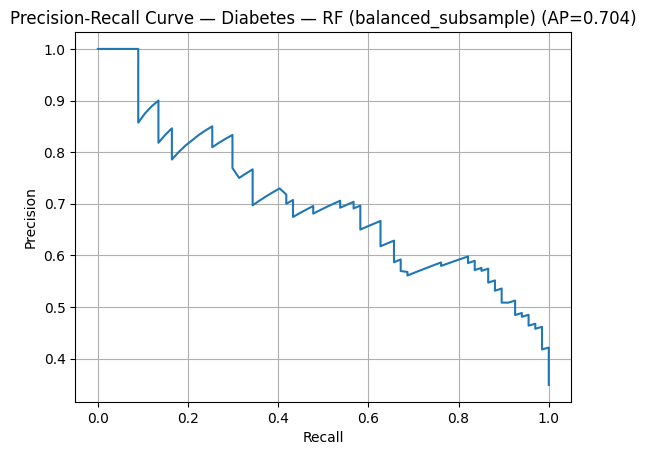

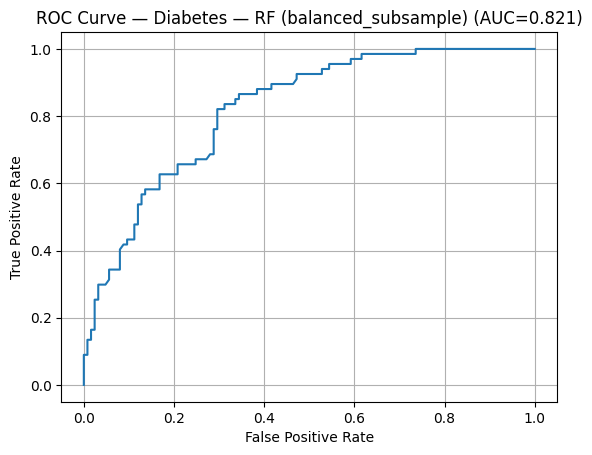

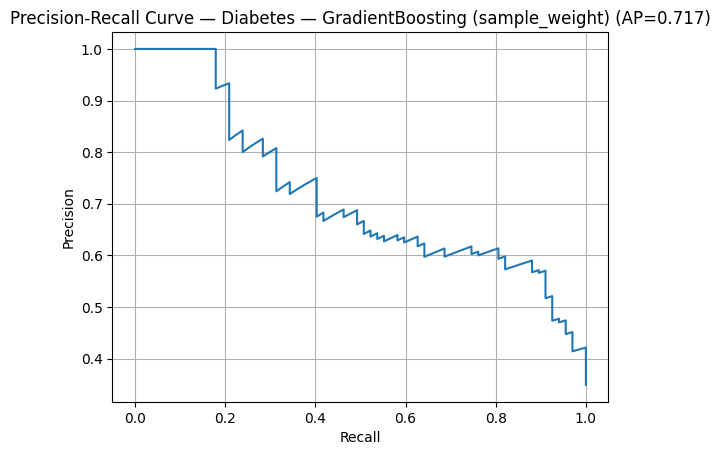

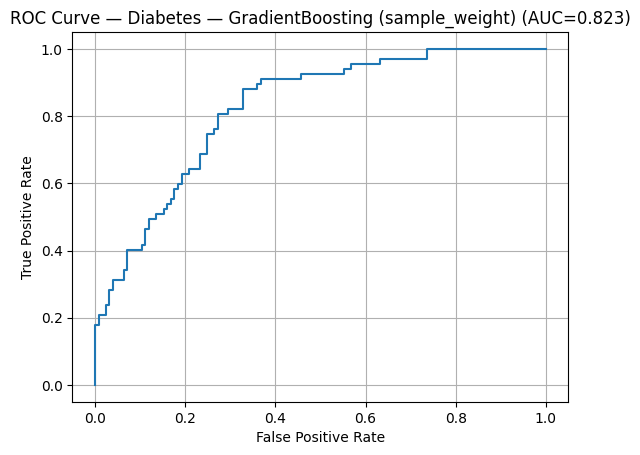

In [6]:
p = get_diabetes_preds()
y_test = p["y_test"]

plot_pr_roc(y_test, p["p_lr"], "Diabetes — LogisticRegression")
plot_pr_roc(y_test, p["p_rf"], "Diabetes — RandomForest")
plot_pr_roc(y_test, p["p_rf_bsub"], "Diabetes — RF (balanced_subsample)")
plot_pr_roc(y_test, p["p_gb"], "Diabetes — GradientBoosting (sample_weight)")

TP             49.000000
FP             27.000000
TN             98.000000
FN             18.000000
BalancedAcc     0.757672
MCC             0.502289
ROC_AUC         0.832358
PR_AUC          0.713935
Brier           0.167597
Precision       0.644737
Recall          0.731343
Name: BalancedBaggingBinary (LR base), dtype: float64

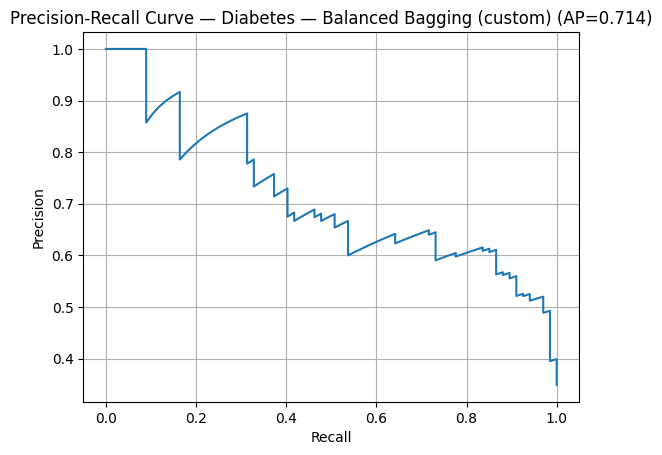

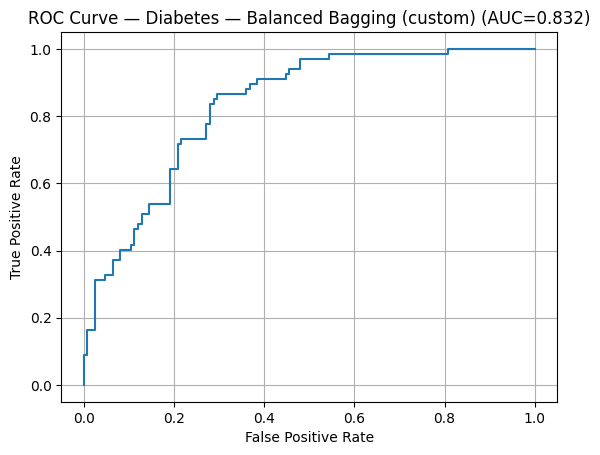

In [7]:
# Balanced bagging (educational) — uses precomputed matrices
p = get_diabetes_preds()
X_train, y_train = p["X_train"], p["y_train"]
X_test = p["X_test"]
y_test = p["y_test"]

pre_custom = make_preprocessor(X_train)
Xtr_mat = pre_custom.fit_transform(X_train)
Xte_mat = pre_custom.transform(X_test)

bb = BalancedBaggingBinary(base_estimator=LogisticRegression(max_iter=3000, solver="lbfgs"),
                           n_estimators=100, random_state=42)
bb.fit(Xtr_mat, y_train)
p_bb = bb.predict_proba(Xte_mat)[:, 1]

display(pd.Series(summarize_binary_metrics(y_test, (p_bb>=0.5).astype(int), p_bb), name="BalancedBaggingBinary (LR base)"))
plot_pr_roc(y_test, p_bb, "Diabetes — Balanced Bagging (custom)")

TP             44.000000
FP             31.000000
TN             94.000000
FN             23.000000
BalancedAcc     0.704358
MCC             0.399292
ROC_AUC         0.826806
PR_AUC          0.723466
Brier           0.162682
Precision       0.586667
Recall          0.656716
Name: BRF (imblearn), dtype: float64

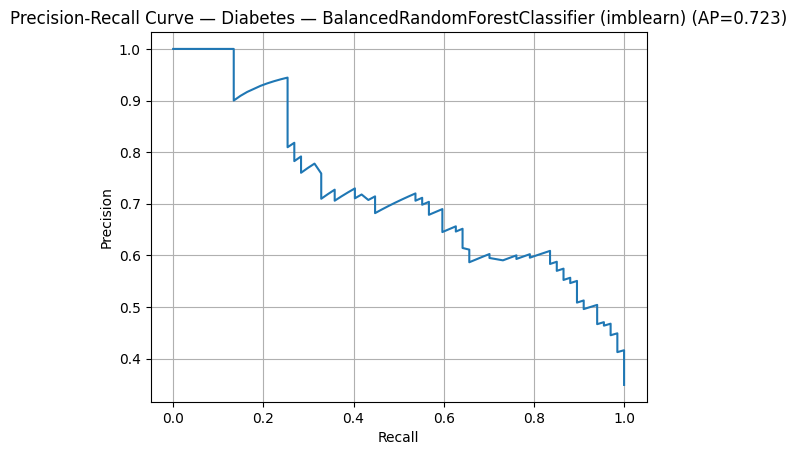

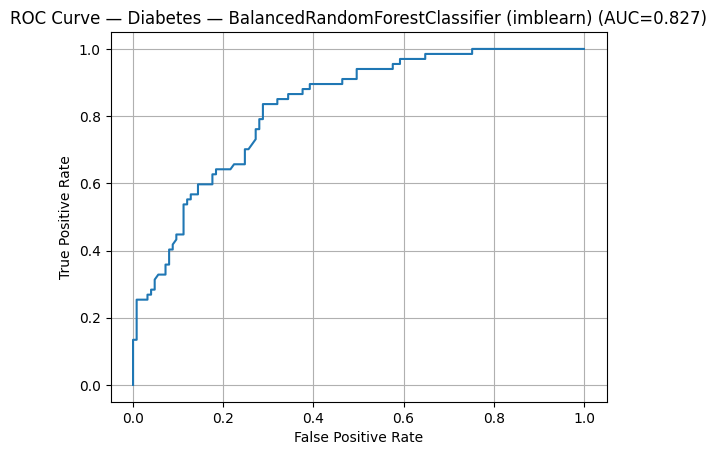

In [8]:
# Optional: imbalanced-learn BalancedRandomForestClassifier (if installed)
d = get_diabetes()
X_train, y_train = d["X_train"], d["y_train"]
X_test, y_test = d["X_test"], d["y_test"]

try:
    from imblearn.ensemble import BalancedRandomForestClassifier

    pipe_brf = Pipeline(steps=[
        ("pre", make_preprocessor(X_train)),
        ("clf", BalancedRandomForestClassifier(
            n_estimators=900,
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipe_brf.fit(X_train, y_train)
    p_brf = pipe_brf.predict_proba(X_test)[:, 1]

    display(pd.Series(summarize_binary_metrics(y_test, (p_brf>=0.5).astype(int), p_brf), name="BRF (imblearn)"))
    plot_pr_roc(y_test, p_brf, "Diabetes — BalancedRandomForestClassifier (imblearn)")
except Exception as e:
    print("imbalanced-learn not available or failed to import:", repr(e))
    print("That's fine — sklearn's class_weight='balanced_subsample' is a strong baseline.")

## ۲) آستانه‌گذاری و کالیبراسیون (دیابت)

آستانه‌ها را برای RF با `balanced_subsample` تیون می‌کنیم و در صورت امکان کالیبراسیون انجام می‌دهیم.

نکته:

- کالیبراسیون با CV ممکن است وقتی کلاس اقلیت خیلی کم باشد شکست بخورد.  
  ما `cv` را بر اساس تعداد کلاس اقلیت به‌صورت خودکار تنظیم می‌کنیم.



,TP,FP,TN,FN,BalancedAcc,MCC,ROC_AUC,PR_AUC,Brier,Precision,Recall
Default (thr=0.50),39.0,18.0,107.0,28.0,0.719045,0.457037,0.821134,0.703816,0.162374,0.684211,0.582090
MaxF1 (thr=0.32),55.0,37.0,88.0,12.0,0.762448,0.500808,0.821134,0.703816,0.162374,0.597826,0.820896
MaxF2 (thr=0.12),64.0,69.0,56.0,3.0,0.701612,0.416569,0.821134,0.703816,0.162374,0.481203,0.955224
MinCost(Cfn=8) (thr=0.09),66.0,81.0,44.0,1.0,0.668537,0.379274,0.821134,0.703816,0.162374,0.448980,0.985075


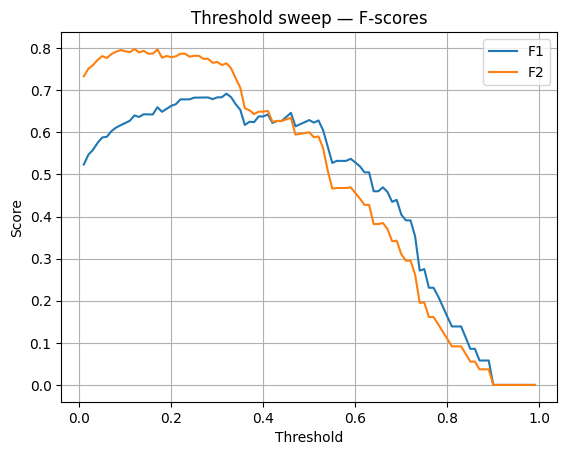

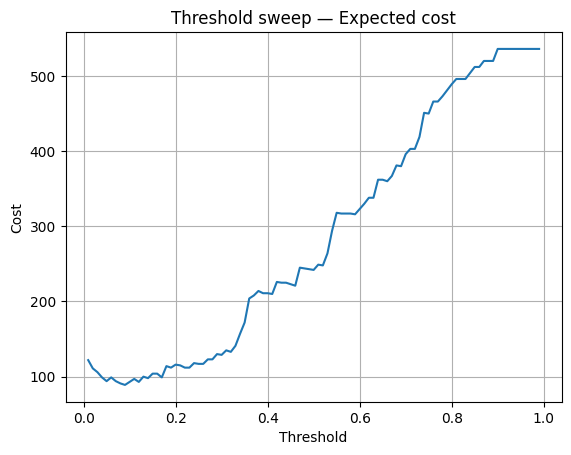

In [9]:
p = get_diabetes_preds()
y_test = p["y_test"]
p_rf_bsub = p["p_rf_bsub"]

df_sweep = threshold_sweep(y_test, p_rf_bsub, C_fp=1.0, C_fn=8.0)
thr_f1, _ = best_threshold_by(df_sweep, "F1")
thr_f2, _ = best_threshold_by(df_sweep, "F2")
thr_cost, _ = best_threshold_by(df_sweep, "Cost(Cfp=1.0,Cfn=8.0)")

display(eval_table(y_test, p_rf_bsub, {
    "Default": 0.5,
    "MaxF1": thr_f1,
    "MaxF2": thr_f2,
    "MinCost(Cfn=8)": thr_cost,
}))

plt.figure()
plt.plot(df_sweep["thr"], df_sweep["F1"], label="F1")
plt.plot(df_sweep["thr"], df_sweep["F2"], label="F2")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold sweep — F-scores")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(df_sweep["thr"], df_sweep["Cost(Cfp=1.0,Cfn=8.0)"])
plt.xlabel("Threshold")
plt.ylabel("Cost")
plt.title("Threshold sweep — Expected cost")
plt.grid(True)
plt.show()

Minority count in y_train: 201 | calibration cv: 3


,Uncalibrated,Calibrated(sigmoid),Calibrated(isotonic)
TP,39.000000,38.000000,40.000000
FP,18.000000,18.000000,21.000000
TN,107.000000,107.000000,104.000000
FN,28.000000,29.000000,27.000000
BalancedAcc,0.719045,0.711582,0.714507
MCC,0.457037,0.443749,0.439202
ROC_AUC,0.821134,0.824955,0.820239
PR_AUC,0.703816,0.722359,0.712954
Brier,0.162374,0.163016,0.164020
Precision,0.684211,0.678571,0.655738


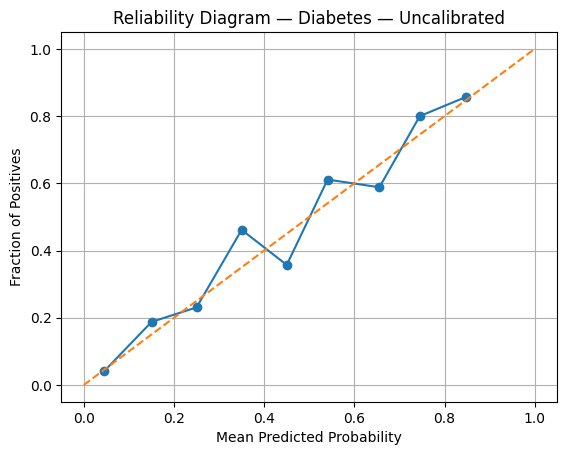

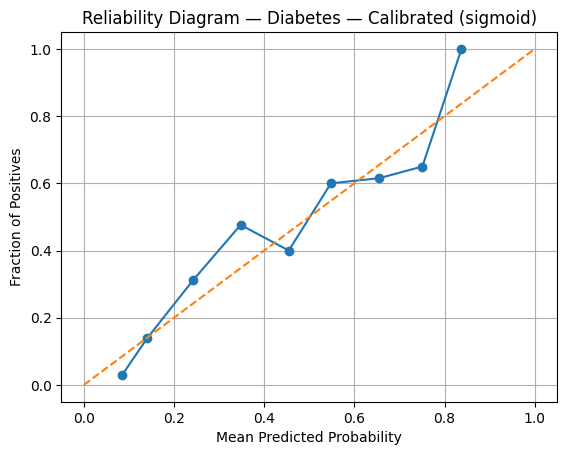

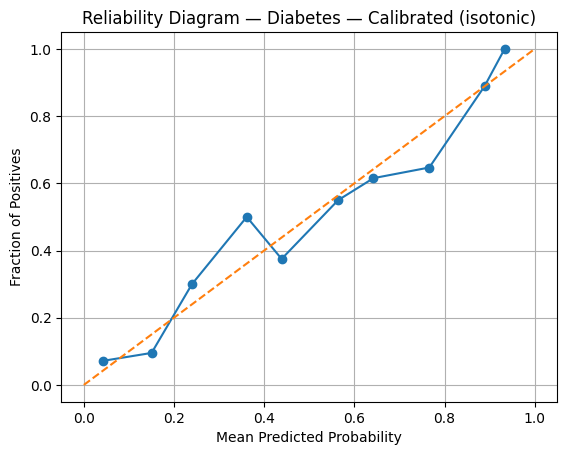

In [10]:
# Calibration (guarded)
d = get_diabetes()
X_train, y_train = d["X_train"], d["y_train"]
X_test, y_test = d["X_test"], d["y_test"]

minority = int(pd.Series(y_train).value_counts().min())
cv = 3 if minority >= 3 else 2

print("Minority count in y_train:", minority, "| calibration cv:", cv)

pipe_rf_bsub = get_diabetes_preds()["pipe_rf_bsub"]

try:
    cal_sig = CalibratedClassifierCV(estimator=pipe_rf_bsub, method="sigmoid", cv=cv)
    cal_iso = CalibratedClassifierCV(estimator=pipe_rf_bsub, method="isotonic", cv=cv)

    cal_sig.fit(X_train, y_train)
    cal_iso.fit(X_train, y_train)

    p_sig = cal_sig.predict_proba(X_test)[:, 1]
    p_iso = cal_iso.predict_proba(X_test)[:, 1]

    display(pd.DataFrame([
        summarize_binary_metrics(y_test, (get_diabetes_preds()["p_rf_bsub"]>=0.5).astype(int), get_diabetes_preds()["p_rf_bsub"]),
        summarize_binary_metrics(y_test, (p_sig>=0.5).astype(int), p_sig),
        summarize_binary_metrics(y_test, (p_iso>=0.5).astype(int), p_iso),
    ], index=["Uncalibrated", "Calibrated(sigmoid)", "Calibrated(isotonic)"]).T)

    plot_calibration(y_test, get_diabetes_preds()["p_rf_bsub"], "Diabetes — Uncalibrated")
    plot_calibration(y_test, p_sig, "Diabetes — Calibrated (sigmoid)")
    plot_calibration(y_test, p_iso, "Diabetes — Calibrated (isotonic)")
except Exception as e:
    print("Calibration failed (likely due to too few minority samples per fold):", repr(e))
    print("Skip calibration for this split; consider more data or fewer CV folds.")

## ۳) Drug200 — دودویی‌سازی رویداد نادر + آستانه با قید precision

رویداد نادر:

- مثبت: `DrugY`
- منفی: سایر داروها

سپس آستانه را طوری تنظیم می‌کنیم که به precision هدف برسیم و recall را بررسی می‌کنیم.



In [11]:
def get_drug200():
    if "drug200" in CACHE:
        return CACHE["drug200"]

    df = read_csv_rel("../../../Datasets/Classification/drug200.csv")
    X, y = split_X_y(df, "Drug")
    y_bin = y.astype(str).str.strip().str.lower().eq("drugy").astype(int)
    require_two_classes(y_bin, "drug200 y_bin")

    X_train, X_test, y_train, y_test, rs = safe_train_test_split(X, y_bin, test_size=0.25, random_state=42)

    out = {"df": df, "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "rs": rs}
    CACHE["drug200"] = out
    return out

def get_drug200_preds():
    if "drug200_preds" in CACHE:
        return CACHE["drug200_preds"]
    d = get_drug200()
    X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]

    pipe_rf = Pipeline([("pre", make_preprocessor(X_train)),
                        ("clf", RandomForestClassifier(n_estimators=900, random_state=42, n_jobs=-1))])
    pipe_rf_bsub = Pipeline([("pre", make_preprocessor(X_train)),
                             ("clf", RandomForestClassifier(n_estimators=900, random_state=42, n_jobs=-1,
                                                           class_weight="balanced_subsample"))])

    pipe_rf.fit(X_train, y_train)
    pipe_rf_bsub.fit(X_train, y_train)

    p_rf = pipe_rf.predict_proba(X_test)[:, 1]
    p_bsub = pipe_rf_bsub.predict_proba(X_test)[:, 1]

    out = {"y_test": y_test, "p_rf": p_rf, "p_bsub": p_bsub}
    CACHE["drug200_preds"] = out
    return out

d2 = get_drug200()
display(d2["df"].head())
display(d2["df"]["Drug"].value_counts())


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

,Drug200 RF,Drug200 RF (balanced_subsample)
TP,23.000000,23.000000
FP,0.000000,0.000000
TN,27.000000,27.000000
FN,0.000000,0.000000
BalancedAcc,1.000000,1.000000
MCC,1.000000,1.000000
ROC_AUC,1.000000,1.000000
PR_AUC,1.000000,1.000000
Brier,0.008207,0.008356
Precision,1.000000,1.000000


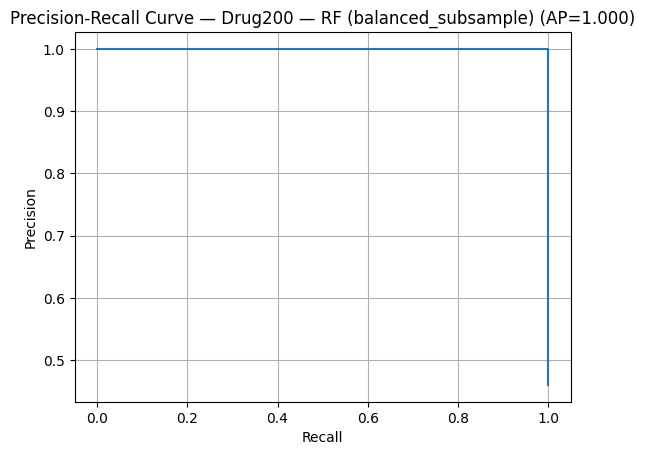

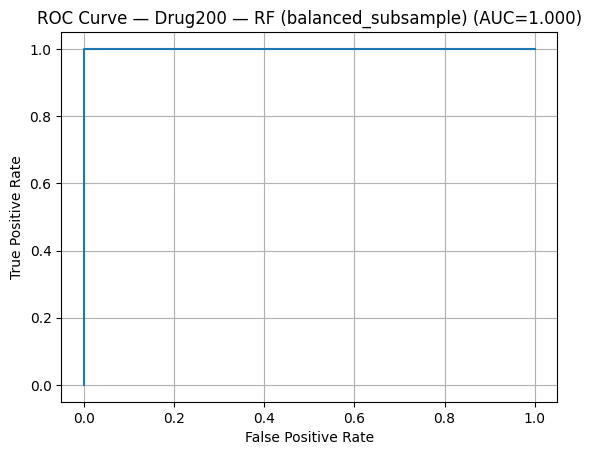

thr for precision>=0.90: 0.11444444444444445 | recall: 1.0
thr for precision>=0.95: 0.15333333333333332 | recall: 1.0


TP             23.000000
FP              2.000000
TN             25.000000
FN              0.000000
BalancedAcc     0.962963
MCC             0.922958
ROC_AUC         1.000000
PR_AUC          1.000000
Brier           0.008356
Precision       0.920000
Recall          1.000000
Name: Drug200 precision>=0.90 (thr=0.114), dtype: float64

TP             23.000000
FP              1.000000
TN             26.000000
FN              0.000000
BalancedAcc     0.981481
MCC             0.960645
ROC_AUC         1.000000
PR_AUC          1.000000
Brier           0.008356
Precision       0.958333
Recall          1.000000
Name: Drug200 precision>=0.95 (thr=0.153), dtype: float64

In [12]:
p2 = get_drug200_preds()
y2 = p2["y_test"]

display(pd.DataFrame([
    summarize_binary_metrics(y2, (p2["p_rf"]>=0.5).astype(int), p2["p_rf"]),
    summarize_binary_metrics(y2, (p2["p_bsub"]>=0.5).astype(int), p2["p_bsub"]),
], index=["Drug200 RF", "Drug200 RF (balanced_subsample)"]).T)

plot_pr_roc(y2, p2["p_bsub"], "Drug200 — RF (balanced_subsample)")

thr_p90, rec_p90 = threshold_for_precision(y2, p2["p_bsub"], precision_target=0.90)
thr_p95, rec_p95 = threshold_for_precision(y2, p2["p_bsub"], precision_target=0.95)

print("thr for precision>=0.90:", thr_p90, "| recall:", rec_p90)
print("thr for precision>=0.95:", thr_p95, "| recall:", rec_p95)

show_operating_point(y2, p2["p_bsub"], thr_p90, "Drug200 precision>=0.90")
show_operating_point(y2, p2["p_bsub"], thr_p95, "Drug200 precision>=0.95")

## ۴) کیفیت واین — رویداد نادر «واین خوب» + آستانه بر اساس هزینه

دودویی‌سازی:

- مثبت: `quality >= 7`
- منفی: سایر

سپس ExtraTrees را با و بدون `balanced_subsample` مقایسه می‌کنیم و آستانه‌ی تجربیِ کم‌هزینه را با $	au^*$ مقایسه می‌کنیم.



In [13]:
def get_wine():
    if "wine" in CACHE:
        return CACHE["wine"]

    df = read_csv_rel("../../../Datasets/Classification/Wine_Quality.csv")
    X, y = split_X_y(df, "quality")
    y_num = pd.to_numeric(y, errors="coerce")
    y_bin = (y_num >= 7).astype(int)
    require_two_classes(y_bin, "wine y_bin")

    X_train, X_test, y_train, y_test, rs = safe_train_test_split(X, y_bin, test_size=0.25, random_state=42)

    out = {"df": df, "X": X, "y_bin": y_bin, "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "rs": rs}
    CACHE["wine"] = out
    return out

def get_wine_preds():
    if "wine_preds" in CACHE:
        return CACHE["wine_preds"]

    d = get_wine()
    X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]

    pipe_et = Pipeline([("pre", make_preprocessor(X_train)),
                        ("clf", ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1))])
    pipe_et_bsub = Pipeline([("pre", make_preprocessor(X_train)),
                             ("clf", ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1,
                                                         class_weight="balanced_subsample"))])

    pipe_et.fit(X_train, y_train)
    pipe_et_bsub.fit(X_train, y_train)

    p_et = pipe_et.predict_proba(X_test)[:, 1]
    p_bsub = pipe_et_bsub.predict_proba(X_test)[:, 1]

    out = {"y_test": y_test, "p_et": p_et, "p_bsub": p_bsub, "y_bin_all": d["y_bin"], "X_all": d["X"]}
    CACHE["wine_preds"] = out
    return out

d3 = get_wine()
display(d3["df"].head())
display(d3["y_bin"].value_counts())
display(d3["y_bin"].value_counts(normalize=True).rename("proportion"))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


quality
0    3838
1    1060
Name: count, dtype: int64

quality
0    0.783585
1    0.216415
Name: proportion, dtype: float64

,Wine ET,Wine ET (balanced_subsample)
TP,167.000000,157.000000
FP,24.000000,18.000000
TN,936.000000,942.000000
FN,98.000000,108.000000
BalancedAcc,0.802594,0.786851
MCC,0.686867,0.675044
ROC_AUC,0.938612,0.938783
PR_AUC,0.855351,0.855531
Brier,0.075383,0.075398
Precision,0.874346,0.897143


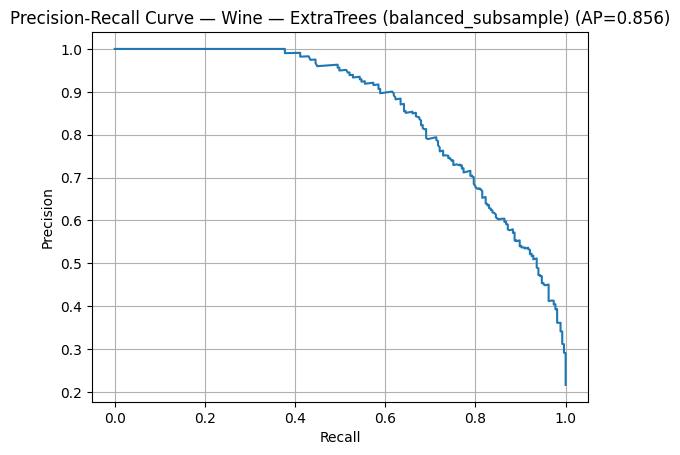

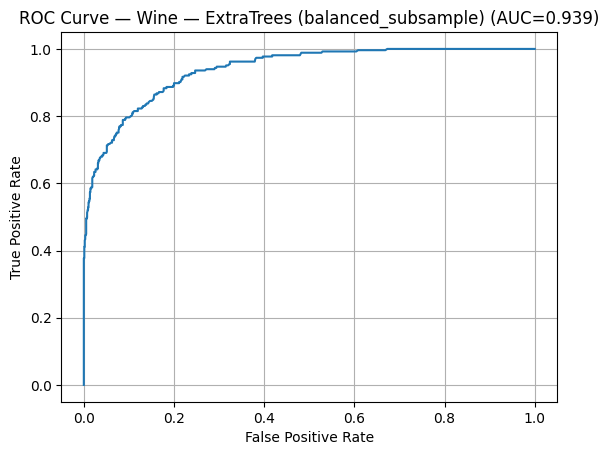

tau_star (theory)                    0.166667
thr_emp (min cost on this test)      0.180000
min_cost_on_test                   324.000000
dtype: float64

,TP,FP,TN,FN,BalancedAcc,MCC,ROC_AUC,PR_AUC,Brier,Precision,Recall
Default (thr=0.50),157.0,18.0,942.0,108.0,0.786851,0.675044,0.938783,0.855531,0.075398,0.897143,0.592453
tau_star (thr=0.17),246.0,237.0,723.0,19.0,0.840713,0.574120,0.938783,0.855531,0.075398,0.509317,0.928302
MinCost(test) (thr=0.18),246.0,229.0,731.0,19.0,0.844880,0.582880,0.938783,0.855531,0.075398,0.517895,0.928302


In [14]:
p3 = get_wine_preds()
y3 = p3["y_test"]

display(pd.DataFrame([
    summarize_binary_metrics(y3, (p3["p_et"]>=0.5).astype(int), p3["p_et"]),
    summarize_binary_metrics(y3, (p3["p_bsub"]>=0.5).astype(int), p3["p_bsub"]),
], index=["Wine ET", "Wine ET (balanced_subsample)"]).T)

plot_pr_roc(y3, p3["p_bsub"], "Wine — ExtraTrees (balanced_subsample)")

C_fp, C_fn = 1.0, 5.0
tau_star = C_fp / (C_fp + C_fn)

df_sweep = threshold_sweep(y3, p3["p_bsub"], C_fp=C_fp, C_fn=C_fn)
col = f"Cost(Cfp={C_fp:.1f},Cfn={C_fn:.1f})"
thr_emp, row_emp = best_threshold_by(df_sweep, col)

display(pd.Series({
    "tau_star (theory)": tau_star,
    "thr_emp (min cost on this test)": thr_emp,
    "min_cost_on_test": float(row_emp[col]),
}))

display(eval_table(y3, p3["p_bsub"], {
    "Default": 0.5,
    "tau_star": tau_star,
    "MinCost(test)": thr_emp,
}))

## ۵) تصادفات NYC — تشخیص خودکار ستون‌ها + ساخت برچسب رویداد نادر

خروجی‌های NYC ممکن است متفاوت باشند. ما:

1) فاصله‌های اضافی نام ستون‌ها را حذف می‌کنیم  
2) ستون مصدومیت را تشخیص می‌دهیم (شامل `PERSON` و `INJUR`)  
3) برچسب رویداد نادر می‌سازیم: injuries >= 3 (اگر تک‌کلاسه شد به >= 1 برمی‌گردیم)



In [15]:
def get_nyc():
    if "nyc" in CACHE:
        return CACHE["nyc"]

    df = read_csv_rel("../../../Datasets/Regression/NYC_Collisions.csv")
    df.columns = [c.strip() for c in df.columns]

    cols_upper = {c: c.upper() for c in df.columns}
    inj_candidates = [c for c,u in cols_upper.items() if ("INJUR" in u and "PERSON" in u)]
    kill_candidates = [c for c,u in cols_upper.items() if ("KILL" in u and "PERSON" in u)]

    inj_col = inj_candidates[0] if inj_candidates else None
    kill_col = kill_candidates[0] if kill_candidates else None

    if inj_col is None:
        raise KeyError("Could not detect an injury-count column. Inspect df.columns.")

    wanted = ["BOROUGH", "ZIP CODE", "LATITUDE", "LONGITUDE", "VEHICLE TYPE", "CONTRIBUTING FACTOR"]
    use_cols = [c for c in wanted if c in df.columns]

    df2 = df[use_cols + [inj_col] + ([kill_col] if kill_col else [])].copy()

    for c in ["ZIP CODE", "LATITUDE", "LONGITUDE", inj_col] + ([kill_col] if kill_col else []):
        if c in df2.columns:
            df2[c] = pd.to_numeric(df2[c], errors="coerce")

    y = (df2[inj_col].fillna(0) >= 3).astype(int)
    if y.nunique() < 2:
        print("Note: injuries>=3 produced a single class; using injuries>=1 instead.")
        y = (df2[inj_col].fillna(0) >= 1).astype(int)
    require_two_classes(y, "nyc y")

    X = df2.drop(columns=[c for c in [inj_col, kill_col] if c and c in df2.columns])

    X_train, X_test, y_train, y_test, rs = safe_train_test_split(X, y, test_size=0.25, random_state=42)

    out = {
        "df": df, "df2": df2, "inj_col": inj_col, "kill_col": kill_col,
        "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "rs": rs
    }
    CACHE["nyc"] = out
    return out

def get_nyc_preds():
    if "nyc_preds" in CACHE:
        return CACHE["nyc_preds"]
    d = get_nyc()
    X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]

    pipe = Pipeline([("pre", make_preprocessor(X_train)),
                     ("clf", RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1,
                                                   class_weight="balanced_subsample"))])
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]

    out = {"y_test": y_test, "p": p}
    CACHE["nyc_preds"] = out
    return out

dnyc = get_nyc()
print("Detected inj_col:", dnyc["inj_col"], "| kill_col:", dnyc["kill_col"])
display(dnyc["df2"].head())
display(pd.Series(dnyc["y_train"]).value_counts().rename("train_count"))
display(pd.Series(dnyc["y_test"]).value_counts().rename("test_count"))

Detected inj_col: PERSONS INJURED | kill_col: PERSONS KILLED


,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,VEHICLE TYPE,CONTRIBUTING FACTOR,PERSONS INJURED,PERSONS KILLED
0,QUEENS,11434.0,40.664536,-73.77314,Station Wagon/Sport Utility Vehicle,Unspecified,0.0,0
1,QUEENS,11355.0,40.754375,-73.82340,Sedan,Unspecified,0.0,0
2,BROOKLYN,11203.0,40.658295,-73.93109,Station Wagon/Sport Utility Vehicle,Driver Inattention/Distraction,1.0,0
3,BROOKLYN,11212.0,40.661873,-73.92878,Sedan,Unspecified,0.0,0
4,NaN,NaN,40.834198,-73.85169,Sedan,Unspecified,1.0,0


PERSONS INJURED
0    91720
1     2363
Name: train_count, dtype: int64

PERSONS INJURED
0    30574
1      788
Name: test_count, dtype: int64

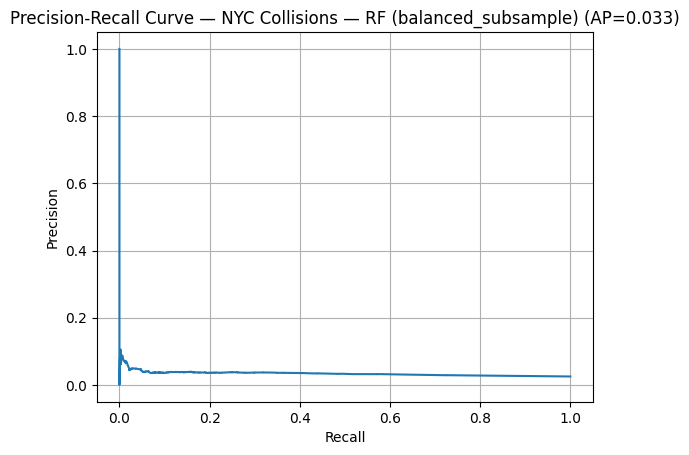

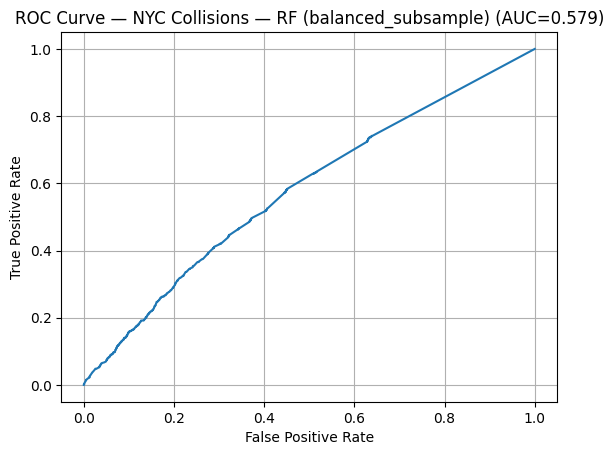

thr for precision>=0.80: None | recall: None
NYC precision>=0.80: no feasible threshold.


In [16]:
pnyc = get_nyc_preds()
plot_pr_roc(pnyc["y_test"], pnyc["p"], "NYC Collisions — RF (balanced_subsample)")

thr_prec, rec_at = threshold_for_precision(pnyc["y_test"], pnyc["p"], precision_target=0.80)
print("thr for precision>=0.80:", thr_prec, "| recall:", rec_at)
show_operating_point(pnyc["y_test"], pnyc["p"], thr_prec, "NYC precision>=0.80")

## ۶) حقوق‌ها — دیتاست خیلی کوچک (دموی رویداد نادر)

چون این دیتاست خیلی کوچک است، آستانه‌های ثابت مثل Salary >= 15000 ممکن است مثبت‌های خیلی کمی بدهد.  
برای اینکه هر دو کلاس وجود داشته باشند، کلاس مثبت را به‌صورت **۲۰٪ بالایی** (quantile) تعریف می‌کنیم (باز هم نسبتاً نادر).



Positive label: Salary >= q80 = 17600.0


,Name,Age,Job,Salary
0,Kevin Sanders,24,Software Engineer,7300
1,Lisa Mills,26,High School Teacher,6100
2,Donna Allison,27,Dentist,12700
3,Michael Schmitt,43,Dentist,17500
4,Lisa Shaffer,31,Accountant,7400


Salary
0    479
1    121
Name: train_count, dtype: int64

Salary
0    319
1     81
Name: test_count, dtype: int64

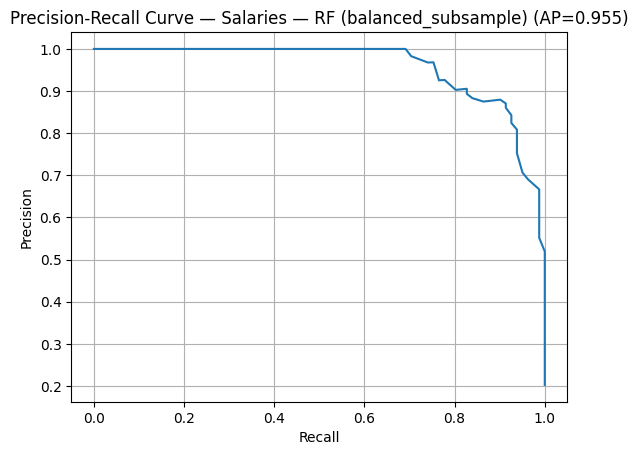

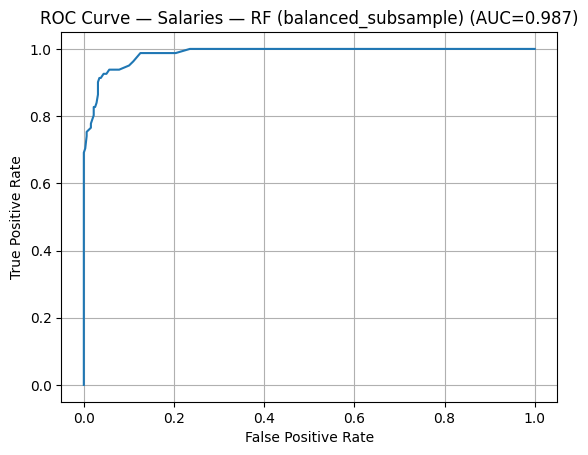

In [17]:
def get_salaries():
    if "salaries" in CACHE:
        return CACHE["salaries"]

    df = read_csv_rel("../../../Datasets/Regression/salaries.csv")
    X, y = split_X_y(df, "Salary")
    y_num = pd.to_numeric(y, errors="coerce")

    q = float(y_num.quantile(0.80))
    y_bin = (y_num >= q).astype(int)
    require_two_classes(y_bin, "salaries y_bin")

    # Slightly larger test fraction is safer for tiny data
    X_train, X_test, y_train, y_test, rs = safe_train_test_split(X, y_bin, test_size=0.40, random_state=42)

    out = {"df": df, "q80": q, "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "rs": rs}
    CACHE["salaries"] = out
    return out

def get_salaries_preds():
    if "salaries_preds" in CACHE:
        return CACHE["salaries_preds"]
    d = get_salaries()
    X_train, X_test, y_train, y_test = d["X_train"], d["X_test"], d["y_train"], d["y_test"]

    pipe = Pipeline([("pre", make_preprocessor(X_train)),
                     ("clf", RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1,
                                                   class_weight="balanced_subsample"))])
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    out = {"y_test": y_test, "p": p}
    CACHE["salaries_preds"] = out
    return out

ds = get_salaries()
print("Positive label: Salary >= q80 =", ds["q80"])
display(ds["df"].head())
display(pd.Series(ds["y_train"]).value_counts().rename("train_count"))
display(pd.Series(ds["y_test"]).value_counts().rename("test_count"))

ps = get_salaries_preds()
plot_pr_roc(ps["y_test"], ps["p"], "Salaries — RF (balanced_subsample)")

## ۷) شیشه — نامتوازن چندکلاسه با `class_weight="balanced"`

ExtraTrees را مقایسه می‌کنیم:

- بدون وزن‌دهی
- با `class_weight="balanced"`

و macro F1 و گزارش کامل را می‌بینیم.



In [18]:
df_glass = read_csv_rel("../../../Datasets/Classification/glass.csv")
Xg, yg = split_X_y(df_glass, "Type")

display(yg.value_counts())
display(yg.value_counts(normalize=True).rename("proportion"))

# Multi-class stratified split
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    Xg, yg, test_size=0.25, random_state=42, stratify=yg
)

pipe_g1 = Pipeline([("pre", make_preprocessor(Xg_train)),
                    ("clf", ExtraTreesClassifier(n_estimators=1000, random_state=42, n_jobs=-1))])

pipe_g2 = Pipeline([("pre", make_preprocessor(Xg_train)),
                    ("clf", ExtraTreesClassifier(n_estimators=1000, random_state=42, n_jobs=-1,
                                                class_weight="balanced"))])

pipe_g1.fit(Xg_train, yg_train)
pipe_g2.fit(Xg_train, yg_train)

pred1 = pipe_g1.predict(Xg_test)
pred2 = pipe_g2.predict(Xg_test)

print("Macro F1 (no weights):", f1_score(yg_test, pred1, average="macro"))
print("Macro F1 (balanced):  ", f1_score(yg_test, pred2, average="macro"))

print("\nReport (no weights):\n")
print(classification_report(yg_test, pred1))

print("\nReport (balanced):\n")
print(classification_report(yg_test, pred2))

Type
building_windows_non_float_processed    76
building_windows_float_processed        70
headlamps                               29
vehicle_windows_float_processed         17
containers                              13
tableware                                9
Name: count, dtype: int64

Type
building_windows_non_float_processed    0.355140
building_windows_float_processed        0.327103
headlamps                               0.135514
vehicle_windows_float_processed         0.079439
containers                              0.060748
tableware                               0.042056
Name: proportion, dtype: float64

Macro F1 (no weights): 0.8231481481481482
Macro F1 (balanced):   0.8055555555555557

Report (no weights):

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.77      0.94      0.85        18
building_windows_non_float_processed       0.94      0.84      0.89        19
                          containers       1.00      1.00      1.00         3
                           headlamps       1.00      1.00      1.00         8
                           tableware       0.67      1.00      0.80         2
     vehicle_windows_float_processed       1.00      0.25      0.40         4

                            accuracy                           0.87        54
                           macro avg       0.90      0.84      0.82        54
                        weighted avg       0.89      0.87      0.86        54


Report (balanced):

                                      precision    recall  f1-score   support

    buildi

## ۸) تیون آستانه بدون leakage (الگوی OOF)

الگوی صحیح:

1) احتمال‌های OOF روی داده‌ی آموزش  
2) تیون آستانه روی OOF  
3) ارزیابی روی test تازه

روی Wine با نسبت هزینه نشان می‌دهیم.



In [19]:
# OOF threshold tuning on Wine
d = get_wine()
X_all, y_all = d["X"], d["y_bin"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_oof = Pipeline([("pre", make_preprocessor(X_all)),
                     ("clf", ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1,
                                                 class_weight="balanced_subsample"))])

p_oof = cross_val_predict(pipe_oof, X_all, y_all, cv=skf, method="predict_proba")[:, 1]

C_fp, C_fn = 1.0, 5.0
df_oof = threshold_sweep(y_all, p_oof, C_fp=C_fp, C_fn=C_fn)
col = f"Cost(Cfp={C_fp:.1f},Cfn={C_fn:.1f})"
thr_oof, row_oof = best_threshold_by(df_oof, col)

print("OOF-tuned threshold:", thr_oof, "| OOF min cost:", float(row_oof[col]))

# Fresh split evaluation
Xtr, Xte, ytr, yte, rs = safe_train_test_split(X_all, y_all, test_size=0.25, random_state=7)

pipe_final = Pipeline([("pre", make_preprocessor(Xtr)),
                       ("clf", ExtraTreesClassifier(n_estimators=1200, random_state=42, n_jobs=-1,
                                                   class_weight="balanced_subsample"))])
pipe_final.fit(Xtr, ytr)
p_te = pipe_final.predict_proba(Xte)[:, 1]

display(eval_table(yte, p_te, {"Default": 0.5, "OOF tuned": thr_oof}))

OOF-tuned threshold: 0.23 | OOF min cost: 1384.0


,TP,FP,TN,FN,BalancedAcc,MCC,ROC_AUC,PR_AUC,Brier,Precision,Recall
Default (thr=0.50),156.0,26.0,934.0,109.0,0.780798,0.650137,0.932726,0.836521,0.080178,0.857143,0.588679
OOF tuned (thr=0.23),235.0,190.0,770.0,30.0,0.844438,0.595882,0.932726,0.836521,0.080178,0.552941,0.886792


## پیوست — اصلاح در تغییر شیوع (اختیاری)

در تغییر صرفاً شیوع (prior shift)، یک اصلاح تقریبی:

$$
\text{logit}(p_{deploy}(x)) = \text{logit}(p_{train}(x)) + 
\log\frac{\pi_{deploy}(1-\pi_{train})}{\pi_{train}(1-\pi_{deploy})}.
$$

پس باید شیوع را در تولید پایش کرد و در صورت تغییر، آستانه را بازتیون کرد.
